saved the figure
Push sideways (along y): r x F = [0. 0. 5.] with r = (0.5, 0, 0) m
Push up (along z): r x F = [ 0. -5.  0.] with r = (0.5, 0, 0) m
Push along the lever (along x): r x F = [0. 0. 0.] with r = (0.5, 0, 0) m


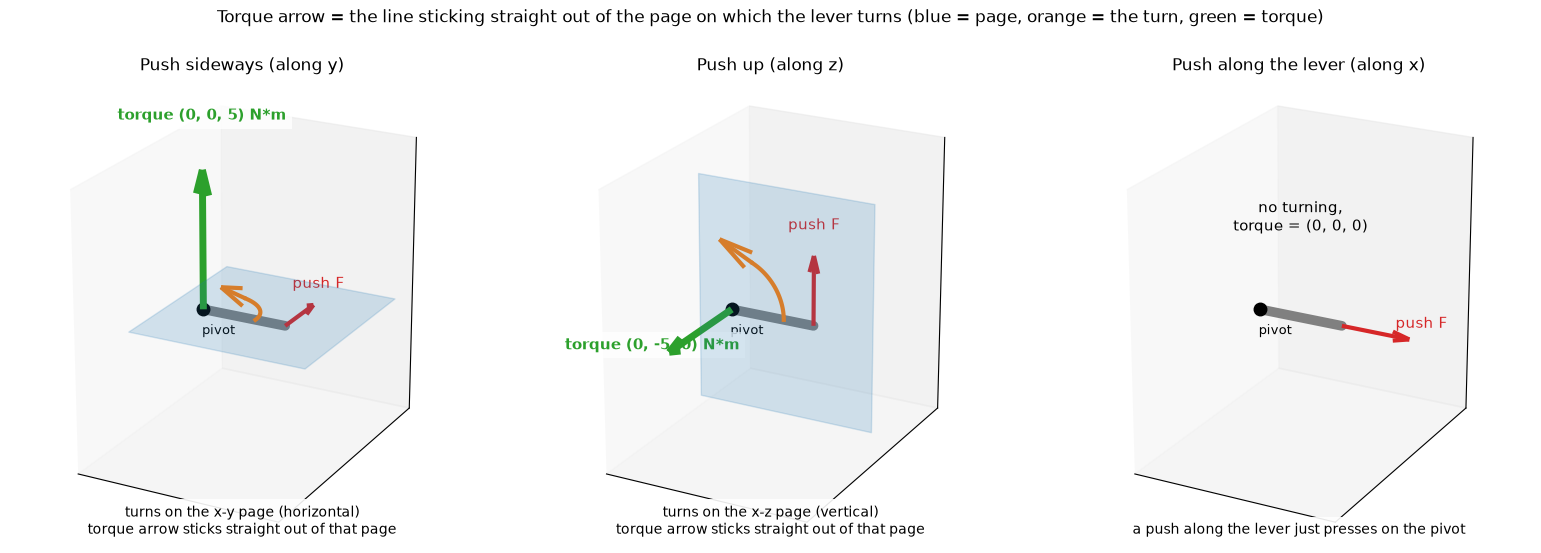

In [1]:
import os
import numpy as np  # type: ignore
import matplotlib.pyplot as plt  # type: ignore
from mpl_toolkits.mplot3d.art3d import Poly3DCollection  # type: ignore
from datetime import datetime

RESULT_DIR = os.path.join(os.getcwd(), "result")
os.makedirs(RESULT_DIR, exist_ok=True)
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

# ─────────────────────────────────────────────
# STEP 1: A spin lives on a "page"; the torque arrow names the page
#
# What we have: a lever r = (0.5, 0, 0) m along x, and a push F of 10 N in three different directions.
# What we want: to see on which flat page (plane) the lever turns, and which arrow names that page.
# Why: in 2D your torque is one signed number on ONE page. In 3D there are many possible pages.
#      The torque arrow tells you the page by pointing straight out of it (perpendicular to it).
#
# Torque from tau = r x F (N*m):
#   F = (0, 10, 0) sideways -> tau = (0, 0, +5)   page = x-y (horizontal), arrow along +z
#   F = (0, 0, 10) up       -> tau = (0, -5, 0)   page = x-z (vertical),   arrow along -y
#   F = (10, 0, 0) along r  -> tau = (0, 0, 0)    no page, no turning
# ─────────────────────────────────────────────

lever = np.array([0.5, 0.0, 0.0])  # m
cases = [
    ("Push sideways (along y)", np.array([0.0, 10.0, 0.0]), "x-y page (horizontal)"),
    ("Push up (along z)", np.array([0.0, 0.0, 10.0]), "x-z page (vertical)"),
    ("Push along the lever (along x)", np.array([10.0, 0.0, 0.0]), "no page"),
]

fig = plt.figure(figsize=(16, 5.6))
for k, (title, F, page_name) in enumerate(cases):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    tau = np.cross(lever, F)
    # the lever
    ax.plot([0, lever[0]], [0, lever[1]], [0, lever[2]], color="gray", linewidth=7, solid_capstyle="round")
    ax.plot([0], [0], [0], "o", color="black", markersize=9)
    ax.text(0.0, -0.02, -0.14, "pivot", fontsize=9)
    # the push (drawn 0.4 long for the picture)
    fdir = F / np.linalg.norm(F)
    ax.quiver(*lever, *(0.4 * fdir), color="C3", linewidth=3, arrow_length_ratio=0.25)
    ax.text(*(lever + 0.47 * fdir + np.array([0, 0, 0.08])), "push F", color="C3", fontsize=11, ha="center")
    if np.linalg.norm(tau) > 0:
        # the page the lever turns on: spanned by the lever direction and the push direction
        u, v = np.array([1.0, 0, 0]), fdir
        corners = [-0.2 * u - 0.55 * v + 0.0, 0.85 * u - 0.55 * v, 0.85 * u + 0.75 * v, -0.2 * u + 0.75 * v]
        ax.add_collection3d(Poly3DCollection([[tuple(c) for c in corners]], alpha=0.18, facecolor="C0", edgecolor="C0"))
        # curved arrow: the way the lever turns on its page
        t = np.linspace(0, 1.15, 40)
        arc = np.array([0.32 * np.cos(tt) * u + 0.32 * np.sin(tt) * v for tt in t])
        ax.plot(arc[:, 0], arc[:, 1], arc[:, 2], color="C1", linewidth=3)
        tip, before = arc[-1], arc[-4]
        ax.quiver(*tip, *((tip - before) * 8), color="C1", linewidth=3, arrow_length_ratio=0.9)
        # the torque arrow, perpendicular to the page
        tdir = tau / np.linalg.norm(tau)
        ax.quiver(0, 0, 0, *(0.8 * tdir), color="C2", linewidth=5, arrow_length_ratio=0.18)
        ax.text(*(1.0 * tdir + np.array([0, 0, 0.08])), f"torque {tuple(int(x) for x in tau)} N*m", color="C2", fontsize=11, fontweight="bold", ha="center", bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
        ax.text2D(0.5, 0.02, f"turns on the {page_name}\ntorque arrow sticks straight out of that page", transform=ax.transAxes, ha="center", fontsize=10, bbox=dict(facecolor="white", edgecolor="none", alpha=0.9))
    else:
        ax.text(0.25, 0.0, 0.5, "no turning,\ntorque = (0, 0, 0)", fontsize=11, ha="center")
        ax.text2D(0.5, 0.02, "a push along the lever just presses on the pivot", transform=ax.transAxes, ha="center", fontsize=10, bbox=dict(facecolor="white", edgecolor="none", alpha=0.9))
    ax.set_xlim(-0.3, 0.9)
    ax.set_ylim(-1.0, 0.9)
    ax.set_zlim(-0.7, 0.9)
    ax.set_box_aspect((1.2, 1.6, 1.6))
    ax.view_init(elev=22, azim=-62)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_title(title, fontsize=12)
fig.suptitle("Torque arrow = the line sticking straight out of the page on which the lever turns (blue = page, orange = the turn, green = torque)")
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(os.path.join(RESULT_DIR, f"torque_pages_{TIMESTAMP}.png"), dpi=110)
print("saved the figure")
for title, F, _ in cases:
    print(f"{title}: r x F = {np.cross(lever * 1.0, F)} with r = (0.5, 0, 0) m")
plt.show()